In [10]:
from IPython.display import Image
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error as MSE
from sklearn.ensemble import BaggingClassifier , AdaBoostClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score

# Boosting 

- Boosting refers to an ensemble method in which many predictors are trained on and each predictor learns from the errors of its predecssor
- **Boosting** : Ensemble method combining several weak learners to form a strong learner.
- **Weak learner** : Model doing slightly better than random guessing.
- Example of weak learner : Decision Stump (**CART** whose maximum depth is 1)
- An Ensemble of predictors are trained squentially 
- each predictor tries to correct the errors made by its predecessor.

# Adaboost
- Stands for Adaptive Boosting
- Each predictor pays more attention to the instances wronglt predicted by its predecssor
- Achieved by changing the weights of training instances 
- Each predictor is assigned a coefficient (alpha)
- (alpha) depends on the predictor's training error

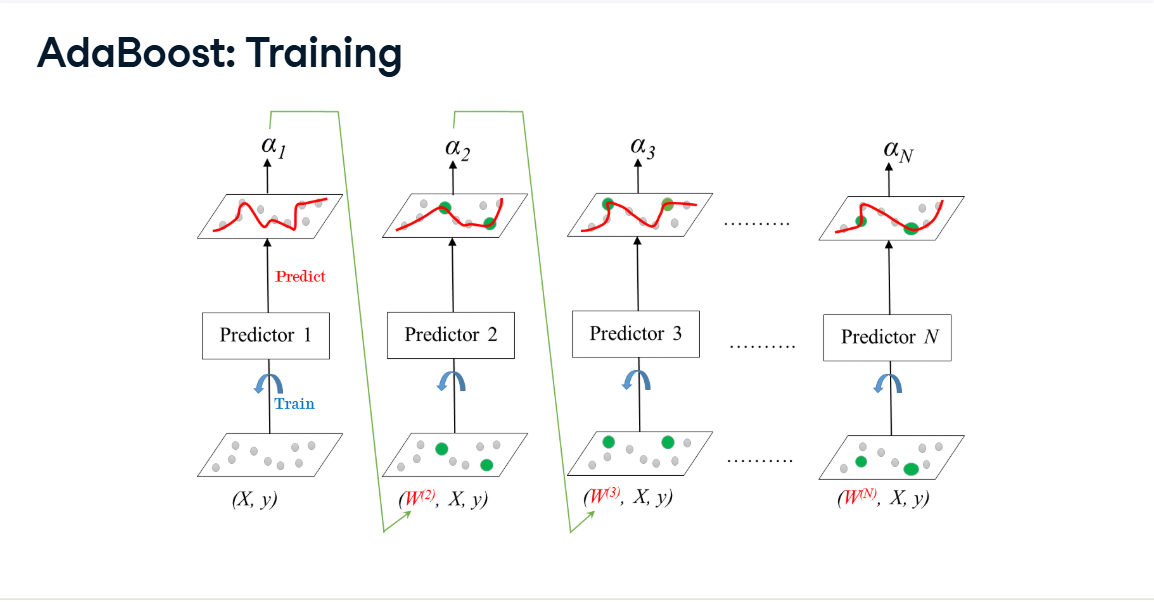
- As shown in the diagran there are N predictors in total .
- First, **predictor1** is trained on the initial dataset **(x,y)** and **the** training error for **predictor1** is determined
- This error can then be used to detrermine **alpha1** which is predictors coefficient. **Alpha1** is then used to determine the weights **W2** of the training instances for **predictor2** . Notice how the incorrectly predicted instances shown in green acquire higher weights . When the weighted instances are used to train **predictor2** , this predictor is forced to pay more attention to the incorrectly predicted instances 
- This proccess is repeated sequentially , until the N predictors forming the ensemble are trained 

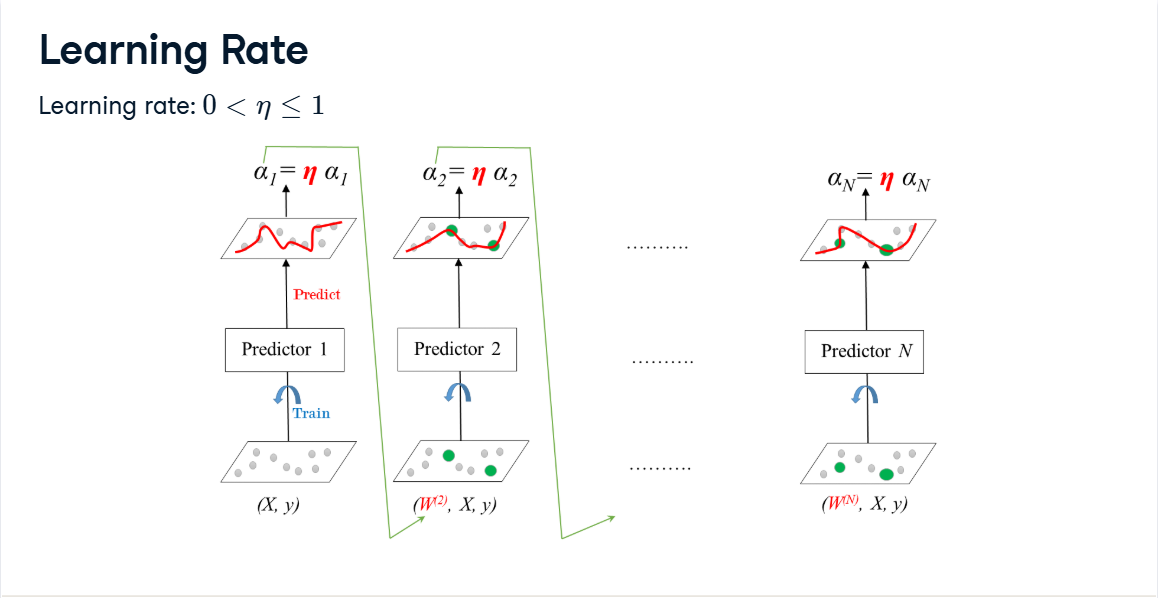
- An important parameter used in training is the learning rate , **η**
- **η** is a number between **0** and **1** 
- it is used to shrink the coefficient alpha of a trained predictor 
- It is important too note that there's a trade off between **η** and the number of estimators
- A smaller value of **η** should be compensated by a greateer number of estimators

# Adaboost Prediction
- Once all the predictors in the ensemble are trained , the label of a new instance can be predicted depending on the nature of the problem
- For **Classification**
    - Weighted majority voting
    - In sklearn : *AdaBoostClassifier*
- For **Regression**
    - Weighted Average 
    - In sklearn *AdaBoostRegression*

In [6]:
df = pd.read_csv(r"../../3. Bagging/breast-cancer.csv")

In [12]:
X = df.drop('diagnosis', axis=1).to_numpy()
y_labels = df['diagnosis'].to_numpy()

SEED=1 

X_train, X_test, y_train, y_test = train_test_split(X, y_labels, test_size=0.3, stratify=y_labels, random_state=SEED)

dt = DecisionTreeClassifier(max_depth=1,random_state=SEED)

adb_clf = AdaBoostClassifier(estimator=dt,n_estimators=100)

adb_clf.fit(X_train,y_train)

y_pred_proba = adb_clf.predict_proba(X_test)[:,1]

adb_clf_roc_auc_score = roc_auc_score(y_test,y_pred_proba)

print("ROC AUC SCORE : {:.2f}".format(adb_clf_roc_auc_score))

ROC AUC SCORE : 0.99
